# 03 - Poisson Goals Model

Fit per-team attack and defense strengths, visualize them, draw a scoreline heatmap for a fixture, and backtest both models.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)

import numpy as np
from wcpredictor.models import EloModel, PoissonModel
from wcpredictor.evaluation import backtest

In [2]:
tr = build_training_matches(load_matches(config), config)
teams = load_teams(config)
poisson = PoissonModel(config).fit(tr)
strengths = poisson.strengths_table(teams)
print('home advantage factor:', round(np.exp(poisson.home_advantage), 3))
strengths.head(15)

home advantage factor: 1.545


,team,attack,defense,net_strength,confederation,pot
0,France,0.356942,0.636575,0.993517,UEFA,1
1,Croatia,0.322289,0.452990,0.775279,UEFA,2
2,Brazil,0.377009,0.347477,0.724486,CONMEBOL,1
3,Spain,0.517926,0.144457,0.662383,UEFA,1
4,Netherlands,0.232175,0.368517,0.600692,UEFA,1
5,Argentina,0.355868,0.183901,0.539769,CONMEBOL,1
6,Germany,0.155992,0.345596,0.501589,UEFA,1
7,Morocco,0.285622,0.171278,0.456901,CAF,1
8,Uruguay,0.351060,0.098283,0.449343,CONMEBOL,1
9,Nigeria,0.050504,0.307173,0.357677,CAF,2


## Attack vs defense

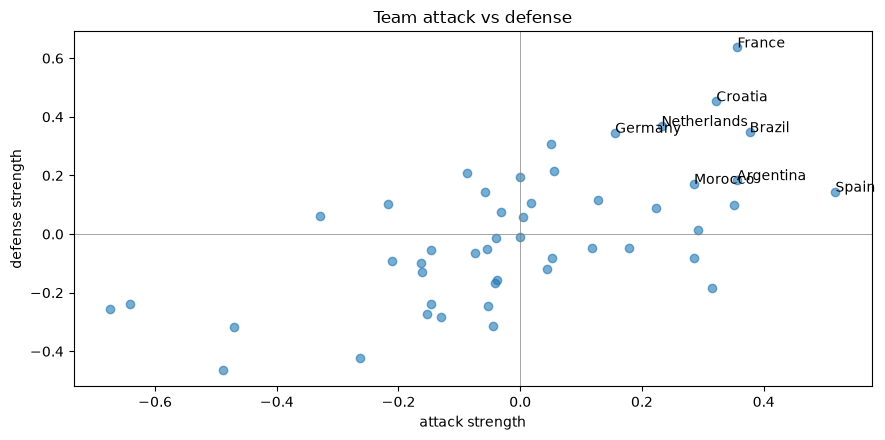

In [3]:
fig, ax = plt.subplots()
ax.scatter(strengths['attack'], strengths['defense'], alpha=0.6)
for _, r in strengths.head(8).iterrows():
    ax.annotate(r['team'], (r['attack'], r['defense']))
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('attack strength'); ax.set_ylabel('defense strength')
ax.set_title('Team attack vs defense'); plt.tight_layout(); plt.show()

## Scoreline probabilities for a fixture

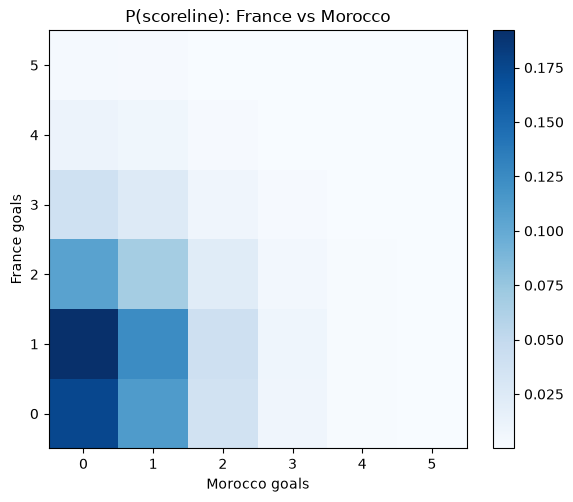

most likely score: (1, 0)


In [4]:
home, away = 'France', 'Morocco'
matrix = poisson.scoreline_matrix(home, away, neutral=True)[:6, :6]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix, cmap='Blues', origin='lower')
ax.set_xlabel(f'{away} goals'); ax.set_ylabel(f'{home} goals')
ax.set_title(f'P(scoreline): {home} vs {away}')
fig.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
print('most likely score:', poisson.most_likely_score(home, away, True))

## Backtest: Elo vs Poisson

Walk-forward evaluation. Lower log-loss / RPS is better.

In [5]:
elo_res = backtest(lambda: EloModel(config), tr, config, min_train=300)
poi_res = backtest(lambda: PoissonModel(config), tr, config, min_train=300)
pd.DataFrame([dict(model='Elo', **elo_res.as_dict()),
              dict(model='Poisson', **poi_res.as_dict())])

,model,accuracy,log_loss,rps,n_matches
0,Elo,0.481373,1.058279,0.222247,1020
1,Poisson,0.483333,1.036619,0.217388,1020
